# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [11]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [12]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [13]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [14]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    x_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"))
    x_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"))
    return x_train-1, y_train-1, x_test-1, y_test-1 
    # raise NotImplementedError("Complete the data-loading function.")

x_train, y_train, x_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = x_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [15]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [16]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation = "relu"),
        layers.Dense(128, activation = "relu"),
        layers.Dense(64, activation = "relu"),
        layers.Dense(6, activation = "softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        )
    return model
        
    # raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 1s 7ms/step - loss: 0.8843 - accuracy: 0.6205 - val_loss: 0.4543 - val_accuracy: 0.8464
Epoch 2/40
92/92 [==============================] - 1s 7ms/step - loss: 0.4334 - accuracy: 0.8298 - val_loss: 0.3194 - val_accuracy: 0.8518
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.3196 - accuracy: 0.8674 - val_loss: 0.2126 - val_accuracy: 0.9313
Epoch 4/40
92/92 [==============================] - 1s 6ms/step - loss: 0.2643 - accuracy: 0.8891 - val_loss: 0.1715 - val_accuracy: 0.9449
Epoch 5/40
92/92 [==============================] - 0s 5ms/step - loss: 0.2386 - accuracy: 0.8964 - val_loss: 0.1645 - val_accuracy: 0.9273
Epoch 6/40
92/92 [==============================] - 0s 5ms/step - loss: 0.2472 - accuracy: 0.8963 - val_loss: 0.1572 - val_accuracy: 0.9388
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.2339 - accuracy: 0.9024 - val_loss: 0.2477 - val_accuracy: 0.8878
Epoch 8/40
92/92 [==

### Training Curves


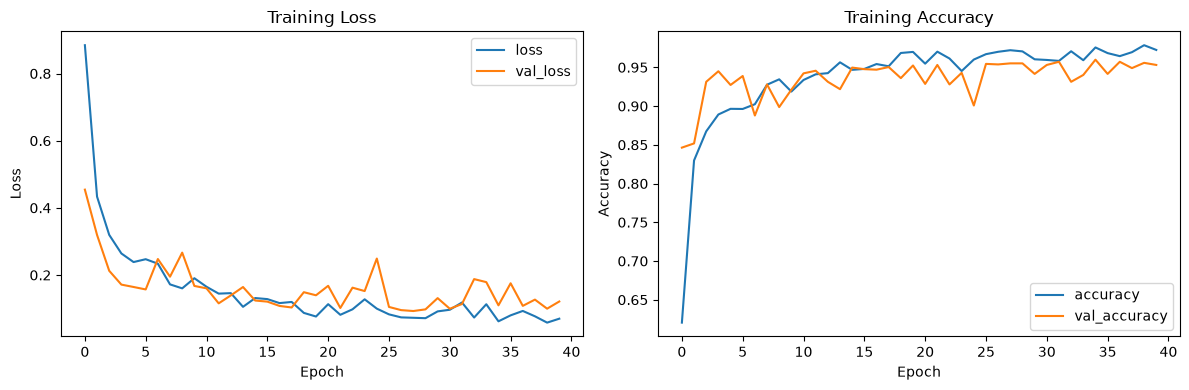

In [18]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


Test Accuracy: 0.9260

                    precision    recall  f1-score   support

           WALKING     0.9540    0.9617    0.9578       496
  WALKING_UPSTAIRS     0.9572    0.9023    0.9290       471
WALKING_DOWNSTAIRS     0.9124    0.9667    0.9387       420
           SITTING     0.9783    0.7332    0.8382       491
          STANDING     0.8025    0.9850    0.8844       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9260      2947
         macro avg     0.9340    0.9248    0.9247      2947
      weighted avg     0.9336    0.9260    0.9250      2947



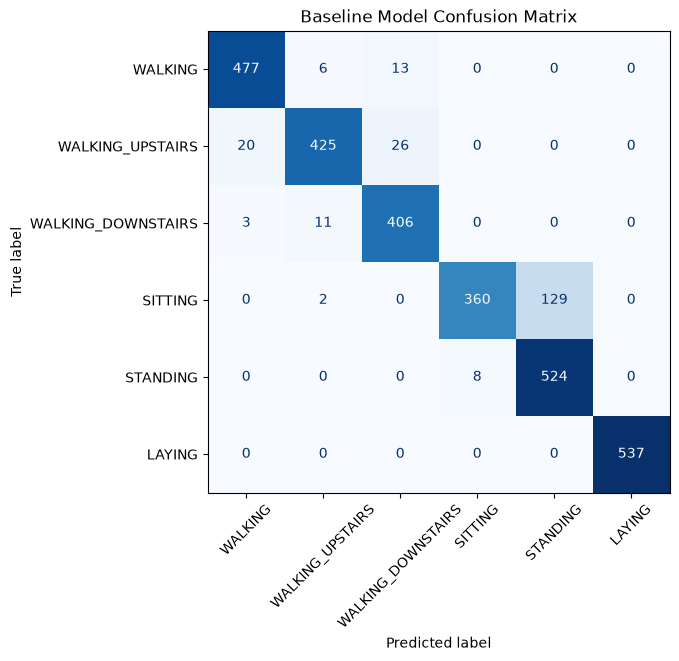

In [57]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
probs = baseline_model.predict(x_test, verbose=0)
preds = np.argmax(probs, axis=1)
test_acc = accuracy_score(y_test, preds)

print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
confusion_matrix=confusion_matrix(y_test, preds),
display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Model Confusion Matrix")
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [44]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    for i in range(300):
        yield [x_train[i:i+1].astype(np.float32)]
        # sample = x_train[i].astype(np.float32)
        # sample = np.expand_dims(sample, axis=0)

        # yield [sample]

    # <-- Enter your code here <--#
    # raise NotImplementedError("Complete the representative dataset generator.")

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

    # <-- Enter your code here <--#

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

    # <-- Enter your code here <--#

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.interface_input_type = tf.int8
    converter.interface_utput_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [45]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
fp32_tflite_model = convert_to_tflite_fp32(baseline_model)
drq_tflite_model = convert_to_tflite_dynamic_range(baseline_model)
float16_tflite_model = convert_to_tflite_float16(baseline_model)
int8_tflite_model = convert_to_tflite_int8(baseline_model)

fp32_size = save_binary_model(fp32_tflite_model, "baseline_fp32.tflite")
drq_size = save_binary_model(drq_tflite_model, "baseline_dynamic_range.tflite")
float16_size = save_binary_model(float16_tflite_model, "baseline_float16.tflite")
int8_size = save_binary_model(int8_tflite_model, "baseline_int8.tflite")

fp32_acc, fp32_preds = evaluate_tflite_model(fp32_tflite_model, x_test, y_test)
drq_acc, drq_preds = evaluate_tflite_model(drq_tflite_model, x_test, y_test)
float16_acc, float16_preds = evaluate_tflite_model(float16_tflite_model, x_test, y_test)
int8_acc, int8_preds = evaluate_tflite_model(int8_tflite_model, x_test, y_test)



INFO:tensorflow:Assets written to: /tmp/tmpm8fsddyg/assets


INFO:tensorflow:Assets written to: /tmp/tmpm8fsddyg/assets
2026-07-21 06:05:29.826289: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 06:05:29.826320: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 06:05:29.826658: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpm8fsddyg
2026-07-21 06:05:29.828628: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 06:05:29.828642: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpm8fsddyg
2026-07-21 06:05:29.834118: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 06:05:29.914970: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpm8fsddyg
2026-07-21 06:05:29.937895: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmppcjadgyx/assets


INFO:tensorflow:Assets written to: /tmp/tmppcjadgyx/assets
2026-07-21 06:05:30.903595: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 06:05:30.903627: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 06:05:30.903920: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmppcjadgyx
2026-07-21 06:05:30.905961: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 06:05:30.905976: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmppcjadgyx
2026-07-21 06:05:30.911454: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 06:05:30.989964: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmppcjadgyx
2026-07-21 06:05:31.011114: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpc2pn43zc/assets


INFO:tensorflow:Assets written to: /tmp/tmpc2pn43zc/assets
2026-07-21 06:05:32.036488: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 06:05:32.036517: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 06:05:32.036802: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpc2pn43zc
2026-07-21 06:05:32.038623: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 06:05:32.038642: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpc2pn43zc
2026-07-21 06:05:32.044300: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 06:05:32.122931: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpc2pn43zc
2026-07-21 06:05:32.146312: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpi9mzzyal/assets


INFO:tensorflow:Assets written to: /tmp/tmpi9mzzyal/assets
/home/vboxuser/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-21 06:05:33.083095: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 06:05:33.083124: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 06:05:33.083434: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpi9mzzyal
2026-07-21 06:05:33.085293: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 06:05:33.085307: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpi9mzzyal
2026-07-21 06:05:33.090395: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


## 10. PTQ Comparison: Accuracy and Model Size


In [46]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
p10rows = [
    {"Model Family": "Baseline", "Format": "FP32",           "Test Accuracy": fp32_acc,            "Model Size (KB)": fp32_size},
    {"Model Family": "Baseline", "Format": "Dynamic Range",  "Test Accuracy": drq_acc,             "Model Size (KB)": drq_size},
    {"Model Family": "Baseline", "Format": "Float16",        "Test Accuracy": float16_acc,         "Model Size (KB)": float16_size},
    {"Model Family": "Baseline", "Format": "INT8",           "Test Accuracy": int8_acc,            "Model Size (KB)": int8_size},
]

p10dataframe = pd.DataFrame(p10rows, columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])
p10table = p10dataframe.style.format({
    "Test Accuracy": "{:.4f}",
    "Model Size (KB)": "{:.2f}"
})
p10table


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.9260,726.75
1,Baseline,Dynamic Range,0.9274,186.14
2,Baseline,Float16,0.9260,365.77
3,Baseline,INT8,0.9281,185.70


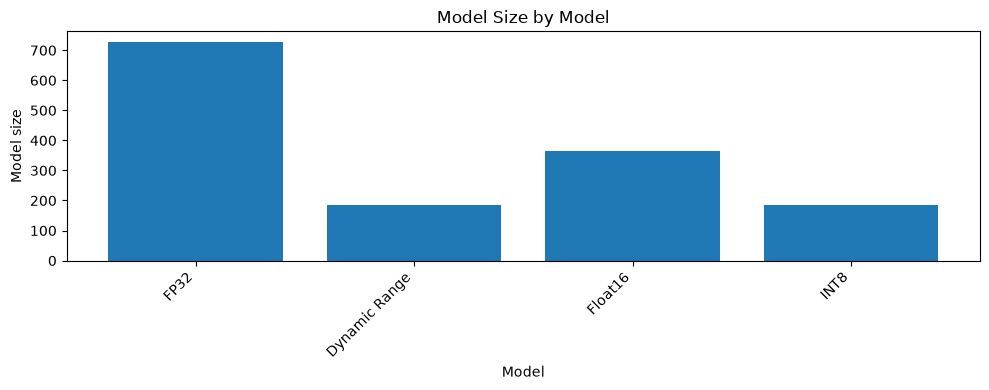

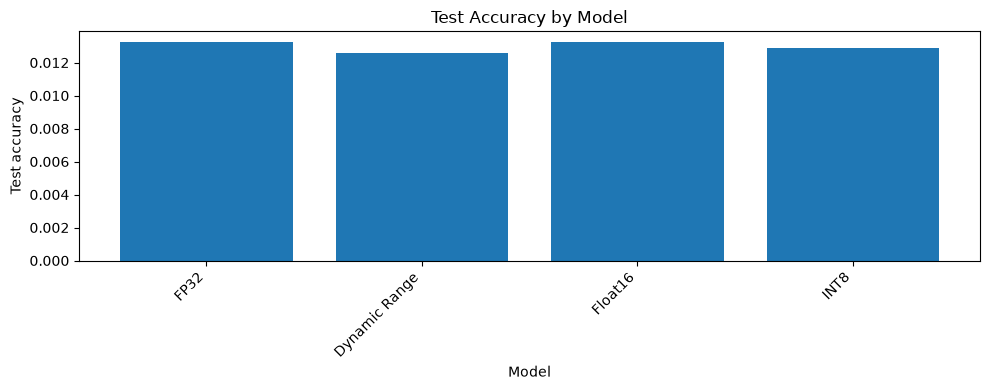

In [47]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
data = dataframe["Format"].astype(str)

plt.figure(figsize=(10, 4))
plt.bar(data, dataframe["Model Size (KB)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Model size")
plt.xlabel("Model")
plt.title("Model Size by Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(data, dataframe["Test Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy")
plt.xlabel("Model")
plt.title("Test Accuracy by Model")
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


Test Accuracy: 0.9281

                    precision    recall  f1-score   support

           WALKING     0.9539    0.9597    0.9568       496
  WALKING_UPSTAIRS     0.9594    0.9023    0.9300       471
WALKING_DOWNSTAIRS     0.9105    0.9690    0.9389       420
           SITTING     0.9786    0.7454    0.8462       491
          STANDING     0.8099    0.9850    0.8889       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9281      2947
         macro avg     0.9354    0.9269    0.9268      2947
      weighted avg     0.9351    0.9281    0.9271      2947



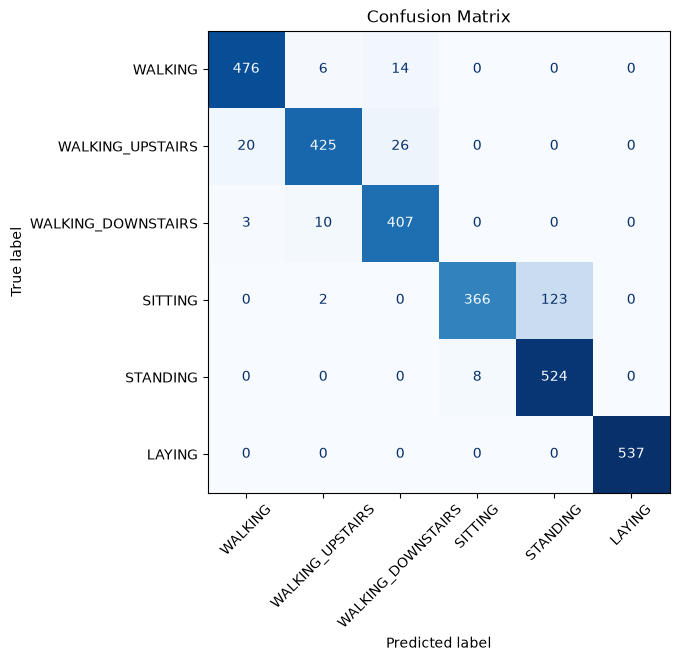

In [48]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

# probs = baseline_model.predict(x_test, verbose=0)
# preds = np.argmax(probs, axis=1)
# test_acc = accuracy_score(y_test, preds)

print(f"Test Accuracy: {int8_acc:.4f}\n")
print(classification_report(y_test, int8_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
confusion_matrix=confusion_matrix(y_test, int8_preds),
display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [49]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
optimizer=keras.optimizers.Adam(learning_rate=1e-4),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)



### Fine-Tune the QAT Model


In [50]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#

qat_history = qat_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 2s 8ms/step - loss: 0.0515 - accuracy: 0.9833 - val_loss: 0.1029 - val_accuracy: 0.9517
Epoch 2/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0427 - accuracy: 0.9845 - val_loss: 0.1003 - val_accuracy: 0.9585
Epoch 3/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0411 - accuracy: 0.9837 - val_loss: 0.1036 - val_accuracy: 0.9599
Epoch 4/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0402 - accuracy: 0.9845 - val_loss: 0.0947 - val_accuracy: 0.9572
Epoch 5/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0384 - accuracy: 0.9866 - val_loss: 0.1158 - val_accuracy: 0.9606
Epoch 6/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0383 - accuracy: 0.9855 - val_loss: 0.0992 - val_accuracy: 0.9592
Epoch 7/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0399 - accuracy: 0.9859 - val_loss: 0.1005 - val_accuracy: 0.9585
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [51]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#

qat_probs = qat_model.predict(x_test, verbose=0)
qat_preds = np.argmax(qat_probs, axis=1)
qat_acc = accuracy_score(y_test, qat_preds)

print(f"QAT Test Accuracy: {qat_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))

# disp = ConfusionMatrixDisplay(
# confusion_matrix=confusion_matrix(y_test-1, qat_preds),
# display_labels=class_names
# )

# fig, ax = plt.subplots(figsize=(8, 6))
# disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
# plt.title("Confusion Matrix")
# plt.show()

QAT Test Accuracy: 0.9457

                    precision    recall  f1-score   support

           WALKING     0.9278    0.9839    0.9550       496
  WALKING_UPSTAIRS     0.9495    0.9172    0.9330       471
WALKING_DOWNSTAIRS     0.9730    0.9452    0.9589       420
           SITTING     0.9609    0.8513    0.9028       491
          STANDING     0.8788    0.9680    0.9213       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9457      2947
         macro avg     0.9483    0.9443    0.9452      2947
      weighted avg     0.9475    0.9457    0.9455      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [53]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_int8_tflite_model = convert_to_tflite_int8(qat_model)
qat_int8_size = save_binary_model(qat_int8_tflite_model, "qat_int8.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite_model,x_test,y_test)

print(f"QAT Int8 Test Accuracy: {qat_int8_acc:.4f}\n")
print(classification_report(y_test, qat_int8_preds, target_names=class_names, digits=4))

INFO:tensorflow:Assets written to: /tmp/tmpfzb3lvsw/assets


INFO:tensorflow:Assets written to: /tmp/tmpfzb3lvsw/assets


QAT Int8 Test Accuracy: 0.9457

                    precision    recall  f1-score   support

           WALKING     0.9278    0.9839    0.9550       496
  WALKING_UPSTAIRS     0.9495    0.9172    0.9330       471
WALKING_DOWNSTAIRS     0.9730    0.9452    0.9589       420
           SITTING     0.9609    0.8513    0.9028       491
          STANDING     0.8788    0.9680    0.9213       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9457      2947
         macro avg     0.9483    0.9443    0.9452      2947
      weighted avg     0.9475    0.9457    0.9455      2947



/home/vboxuser/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-21 06:06:20.946489: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-21 06:06:20.946517: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-21 06:06:20.946885: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfzb3lvsw
2026-07-21 06:06:20.951892: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-21 06:06:20.951917: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfzb3lvsw
2026-07-21 06:06:20.966365: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-21 06:06:21.102024: I tensorflow/cc/saved_model/loa

## 12. PTQ Int8 vs QAT Int8


In [54]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
rows = [
    {"Model Family": "Baseline", "Format": "FP32",           "Test Accuracy": fp32_acc,            "Model Size (KB)": fp32_size},
    {"Model Family": "Baseline", "Format": "Dynamic Range",  "Test Accuracy": drq_acc,             "Model Size (KB)": drq_size},
    {"Model Family": "Baseline", "Format": "Float16",        "Test Accuracy": float16_acc,         "Model Size (KB)": float16_size},
    {"Model Family": "Baseline", "Format": "PAQ INT8",           "Test Accuracy": int8_acc,            "Model Size (KB)": int8_size},
    {"Model Family": "Baseline", "Format": "QAT INT8",       "Test Accuracy": qat_int8_acc,        "Model Size (KB)": qat_int8_size}]

dataframe = pd.DataFrame(rows, columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])
table = dataframe.style.format({
    "Test Accuracy": "{:.4f}",
    "Model Size (KB)": "{:.2f}"
})
table

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.9260,726.75
1,Baseline,Dynamic Range,0.9274,186.14
2,Baseline,Float16,0.9260,365.77
3,Baseline,PAQ INT8,0.9281,185.70
4,Baseline,QAT INT8,0.9457,186.34


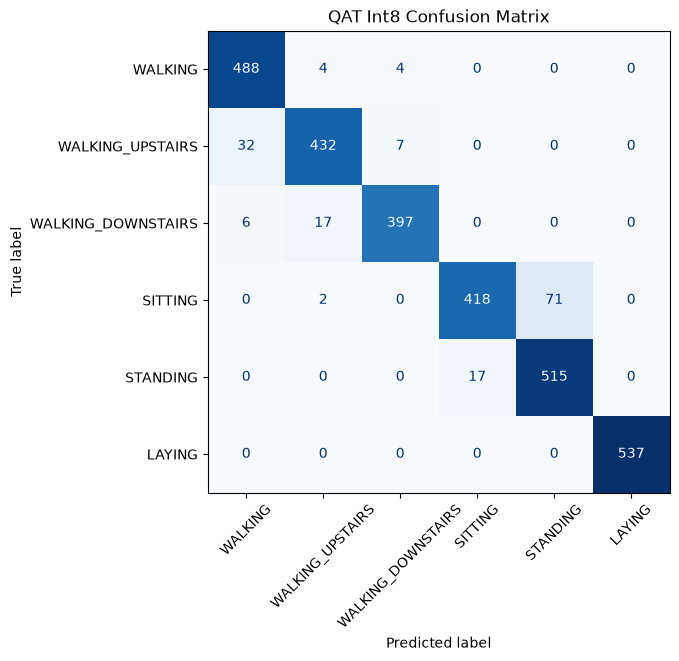

In [56]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
disp = ConfusionMatrixDisplay(
confusion_matrix=confusion_matrix(y_test, qat_int8_preds),
display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT Int8 Confusion Matrix")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
